<a href="https://colab.research.google.com/github/ArmandoBarrios/unidad-4/blob/main/unidad4_practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Unidad 4
#ALUMNO:Armando Barrios
#Practica#1

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#Cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https://drive.google.com/file/d/10jb6-kPt9b-03nwtI_ll8CQeruX1LmZj/view?usp=sharing
file_id ="10jb6-kPt9b-03nwtI_ll8CQeruX1LmZj"
url = f"https://drive.google.com/uc?id={file_id}"
#cargar datos
frutas=pd.read_csv(url)
frutas.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [ ]:
# Variables numéricas
features = ["mass", "width", "height", "color_score"]
X = frutas[features]
# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Inicializar PCA y especificar el número de componentes principales deseados

In [ ]:
pca = PCA(n_components=2) # Elegimos 2 componentes para visualización
X_pca = pca.fit_transform(X_scaled)
# Mostrar la proporción de varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print("Proporción de varianza explicada por cada componente:", explained_variance)
print("Varianza explicada acumulada:", np.cumsum(explained_variance))


Proporción de varianza explicada por cada componente: [0.57845054 0.25650171]
Varianza explicada acumulada: [0.57845054 0.83495225]


Coeficiente de las variables

In [ ]:
# Coeficientes de las variables
componentes = pd.DataFrame(
pca.components_,
columns=X.columns,
index=[f'PC{i+1}' for i in range(pca.n_components_)])
print("Contribución de variables a cada componente:")
print(componentes)

Contribución de variables a cada componente:
         mass     width    height  color_score
PC1  0.626413  0.577999  0.496267    -0.165052
PC2  0.195381  0.254802 -0.238567     0.916509


¿Como saber cuantos componentes son ideales

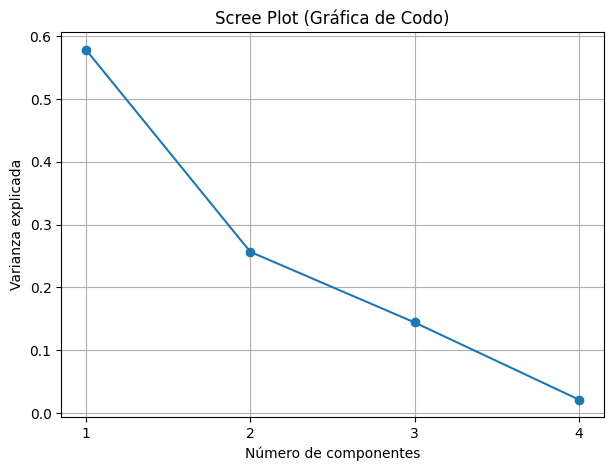

Varianza por componente: [0.57845054 0.25650171 0.14402362 0.02102413]
Varianza acumulada: [0.57845054 0.83495225 0.97897587 1.        ]


In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)
plt.figure(figsize=(7,5))
plt.plot(
range(1, len(pca_full.explained_variance_ratio_) + 1),
pca_full.explained_variance_ratio_,
marker='o'
)
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot (Gráfica de Codo)")
plt.grid(True)
plt.show()
print("Varianza por componente:", pca_full.explained_variance_ratio_)
print("Varianza acumulada:", pca_full.explained_variance_ratio_.cumsum())


Gráfica Biplot

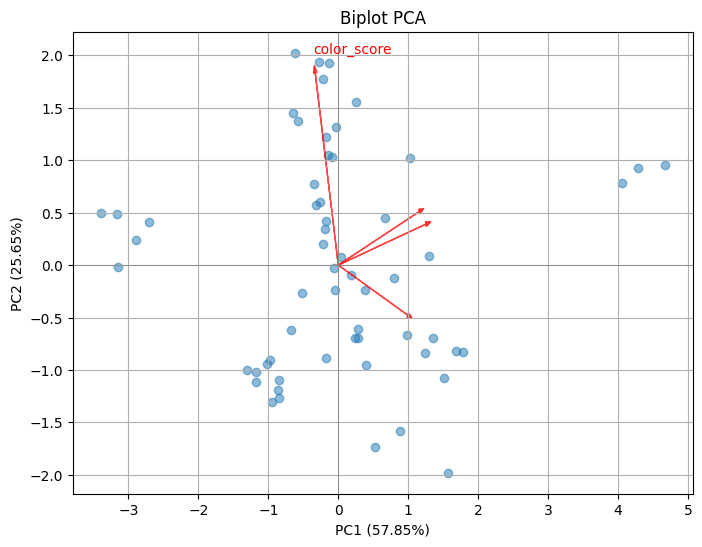

In [ ]:
import matplotlib.pyplot as plt
pca = PCA(n_components=2) # Definimos el PCA con 2 componentes
components = pca.fit_transform(X_scaled) # Calcular el PCA
# Los loadings son los vectores que indican cuánto contribuye cada variable original a cada componente.
# Es una matriz donde: las filas = componentes principales y las columnas = variables con
# valores = coeficientes de contribución
# Si lo transpones (.T), pasan a: filas = variables, columnas = componentes
loadings = pca.components_.T # loadings (vectores)
variables = X.columns # Guarda los nombres de las variables originales,
# por ejemplo ['mass', 'width', 'height', 'color_score']
plt.figure(figsize=(8,6))
# Graficar puntos (scores)
plt.scatter(components[:,0], components[:,1], alpha=0.5)

# Etiquetas de ejes
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
# Graficar vectores (loadings)
for i, var in enumerate(variables):
  plt.arrow(0, 0, loadings[i,0]*2, loadings[i,1]*2,
color='red', alpha=0.7, head_width=0.05)

plt.text(loadings[i,0]*2.2, loadings[i,1]*2.2, var, color='red')

plt.title("Biplot PCA")

plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()